In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score

%matplotlib inline

In [4]:
raw_data = pd.read_csv("https://raw.githubusercontent.com/srikarthadaka/data_science/main/pca/wine.csv")
raw_data

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
raw_data.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [7]:
raw_data.duplicated().sum()

np.int64(0)

In [8]:
raw_data.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [9]:
raw_data['Type'].value_counts()

,count
Type,
2,71
1,59
3,48


In [10]:
raw_data.corr().style.background_gradient(cmap='coolwarm')

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
Type,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoids,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


In [11]:
raw_data.corr()['Type'].sort_values(ascending=False)

,Type
Type,1.000000
Alcalinity,0.517859
Nonflavanoids,0.489109
Malic,0.437776
Color,0.265668
Ash,-0.049643
Magnesium,-0.209179
Alcohol,-0.328222
Proanthocyanins,-0.499130
Hue,-0.617369


In [12]:
raw_data.skew().sort_values(ascending=False)

,0
Magnesium,1.098191
Malic,1.039651
Color,0.868585
Proline,0.767822
Proanthocyanins,0.517137
Nonflavanoids,0.450151
Alcalinity,0.213047
Type,0.107431
Phenols,0.086639
Flavanoids,0.025344


/tmp/ipython-input-1926660289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_data, x=feature,palette='crest', ax=axe[i])
/tmp/ipython-input-1926660289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_data, x=feature,palette='crest', ax=axe[i])
/tmp/ipython-input-1926660289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_data, x=feature,palette='crest', ax=axe[i])
/tmp/ipython-input-1926660289.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

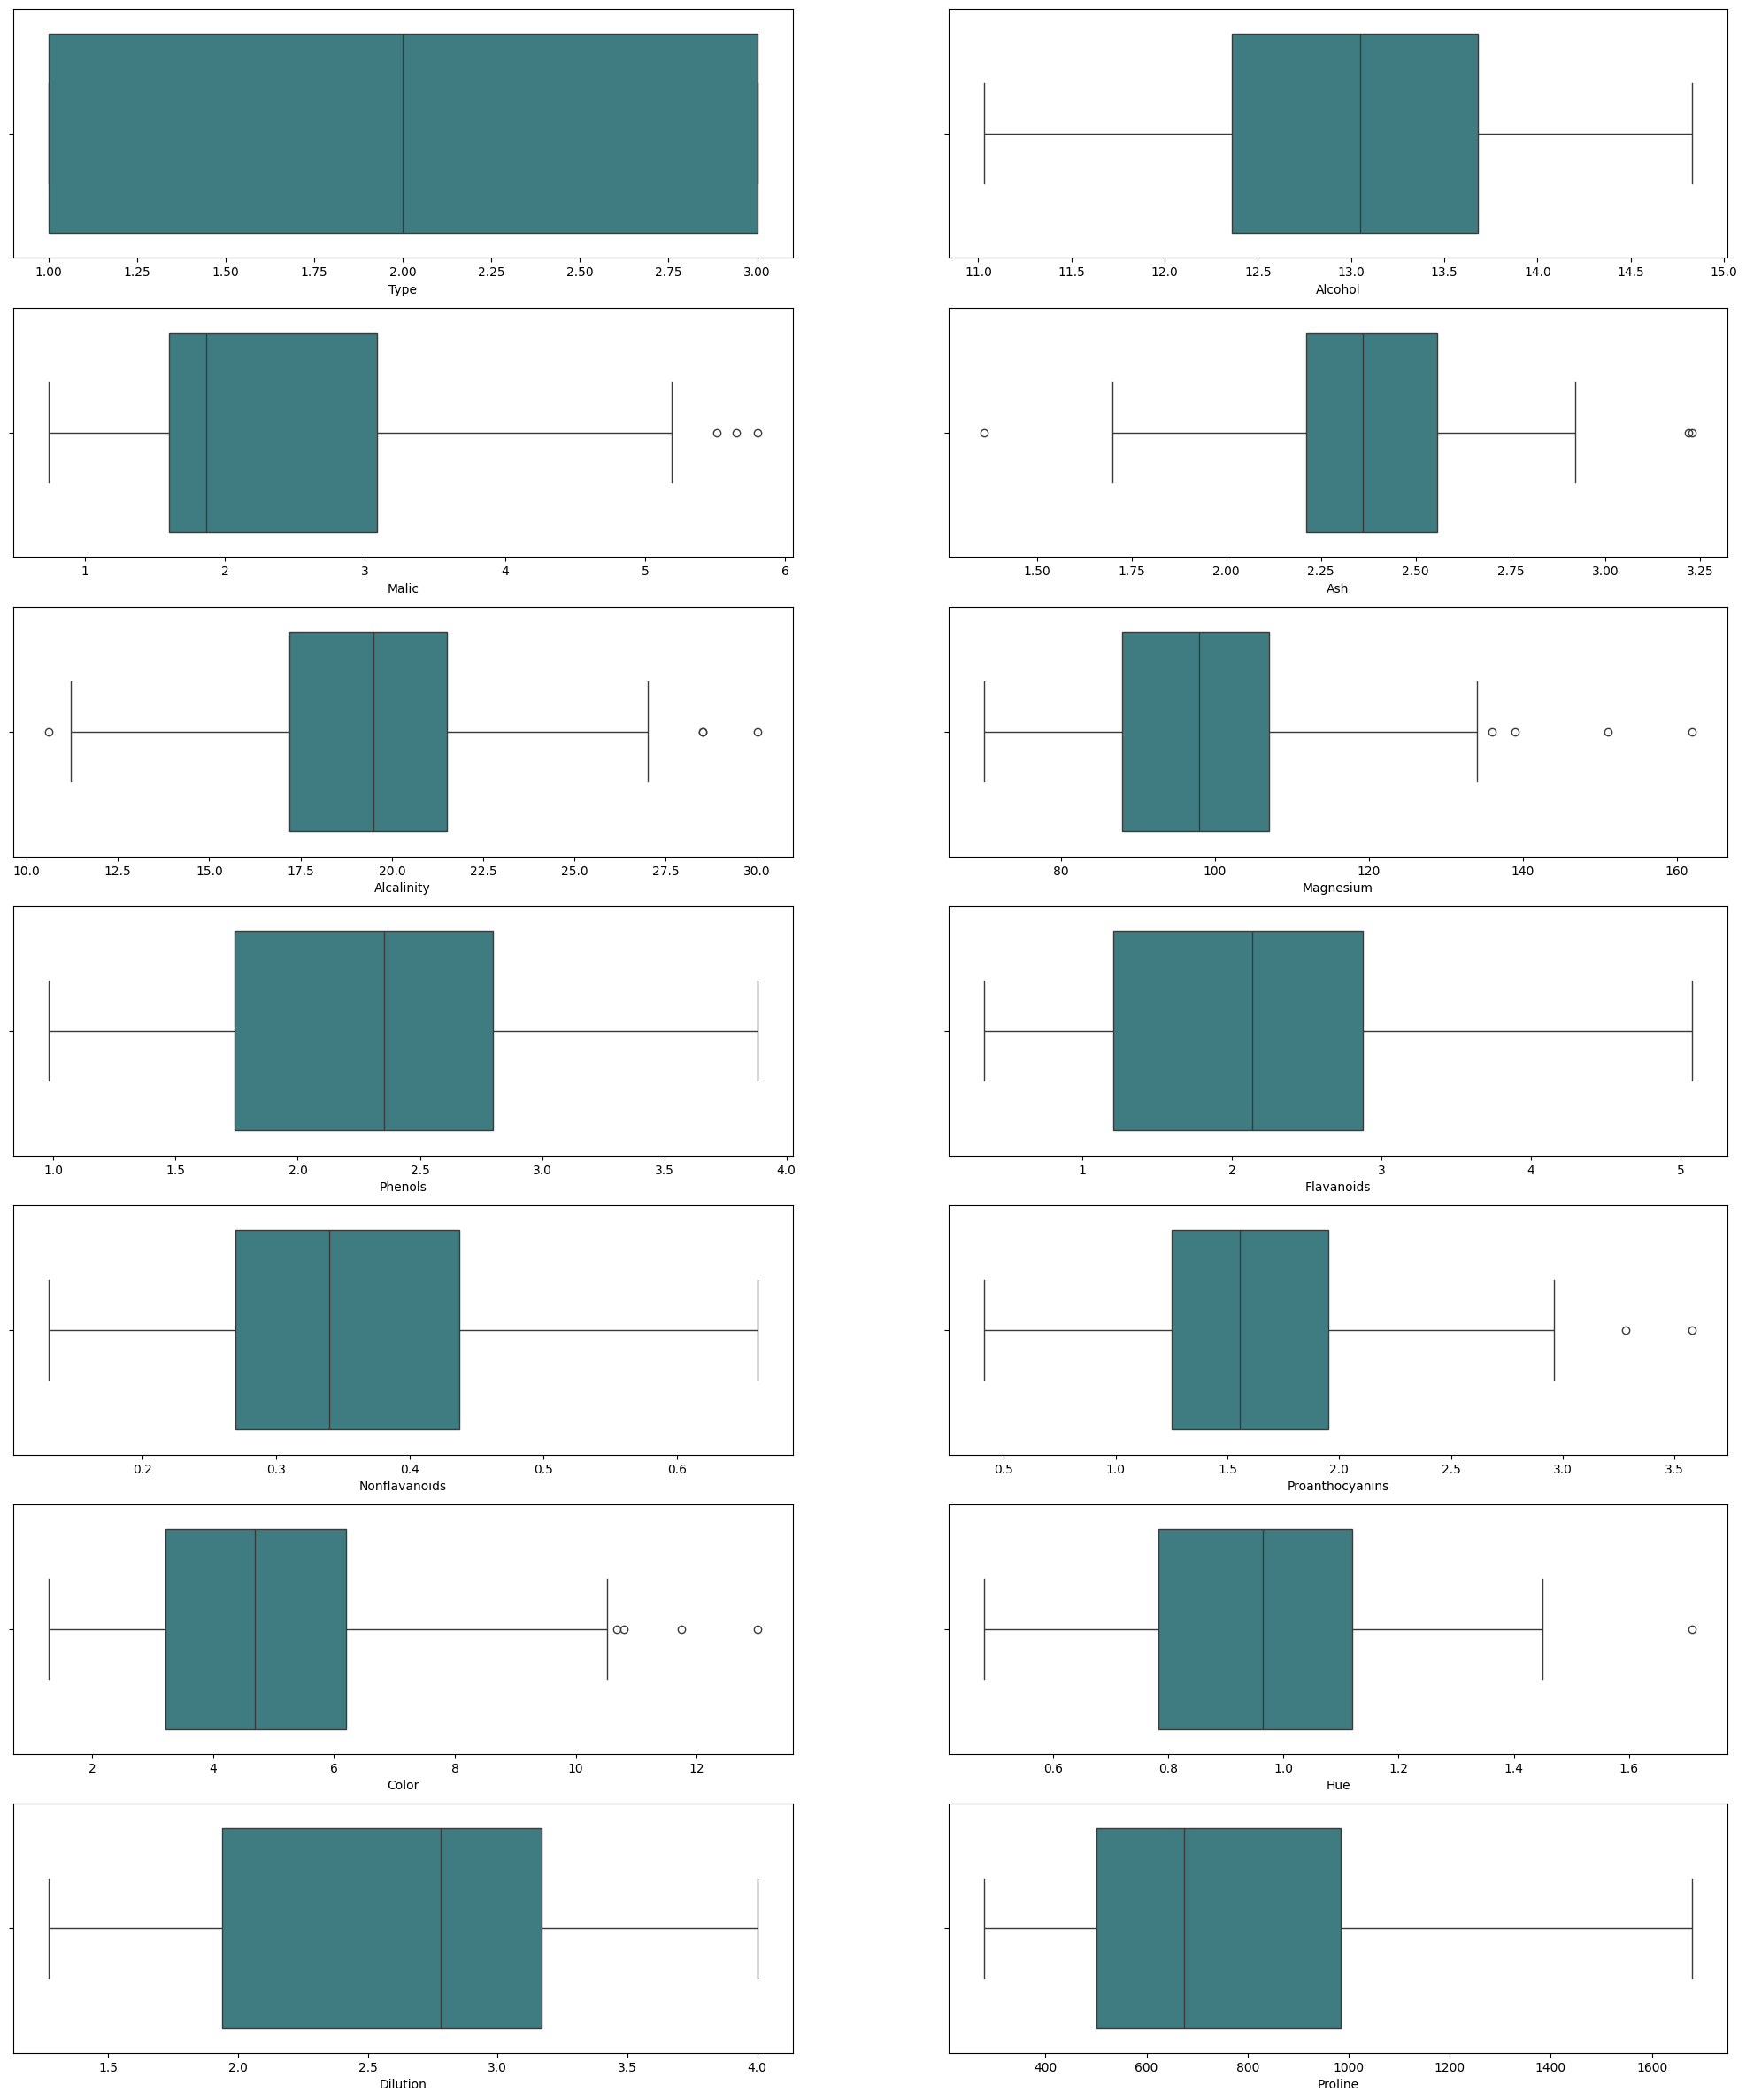

In [13]:
fig, axes=plt.subplots(7,2,figsize=(25,30))
axe = axes.flatten()
for i,feature in enumerate(raw_data.columns):
    sns.boxplot(data=raw_data, x=feature,palette='crest', ax=axe[i])
plt.show()

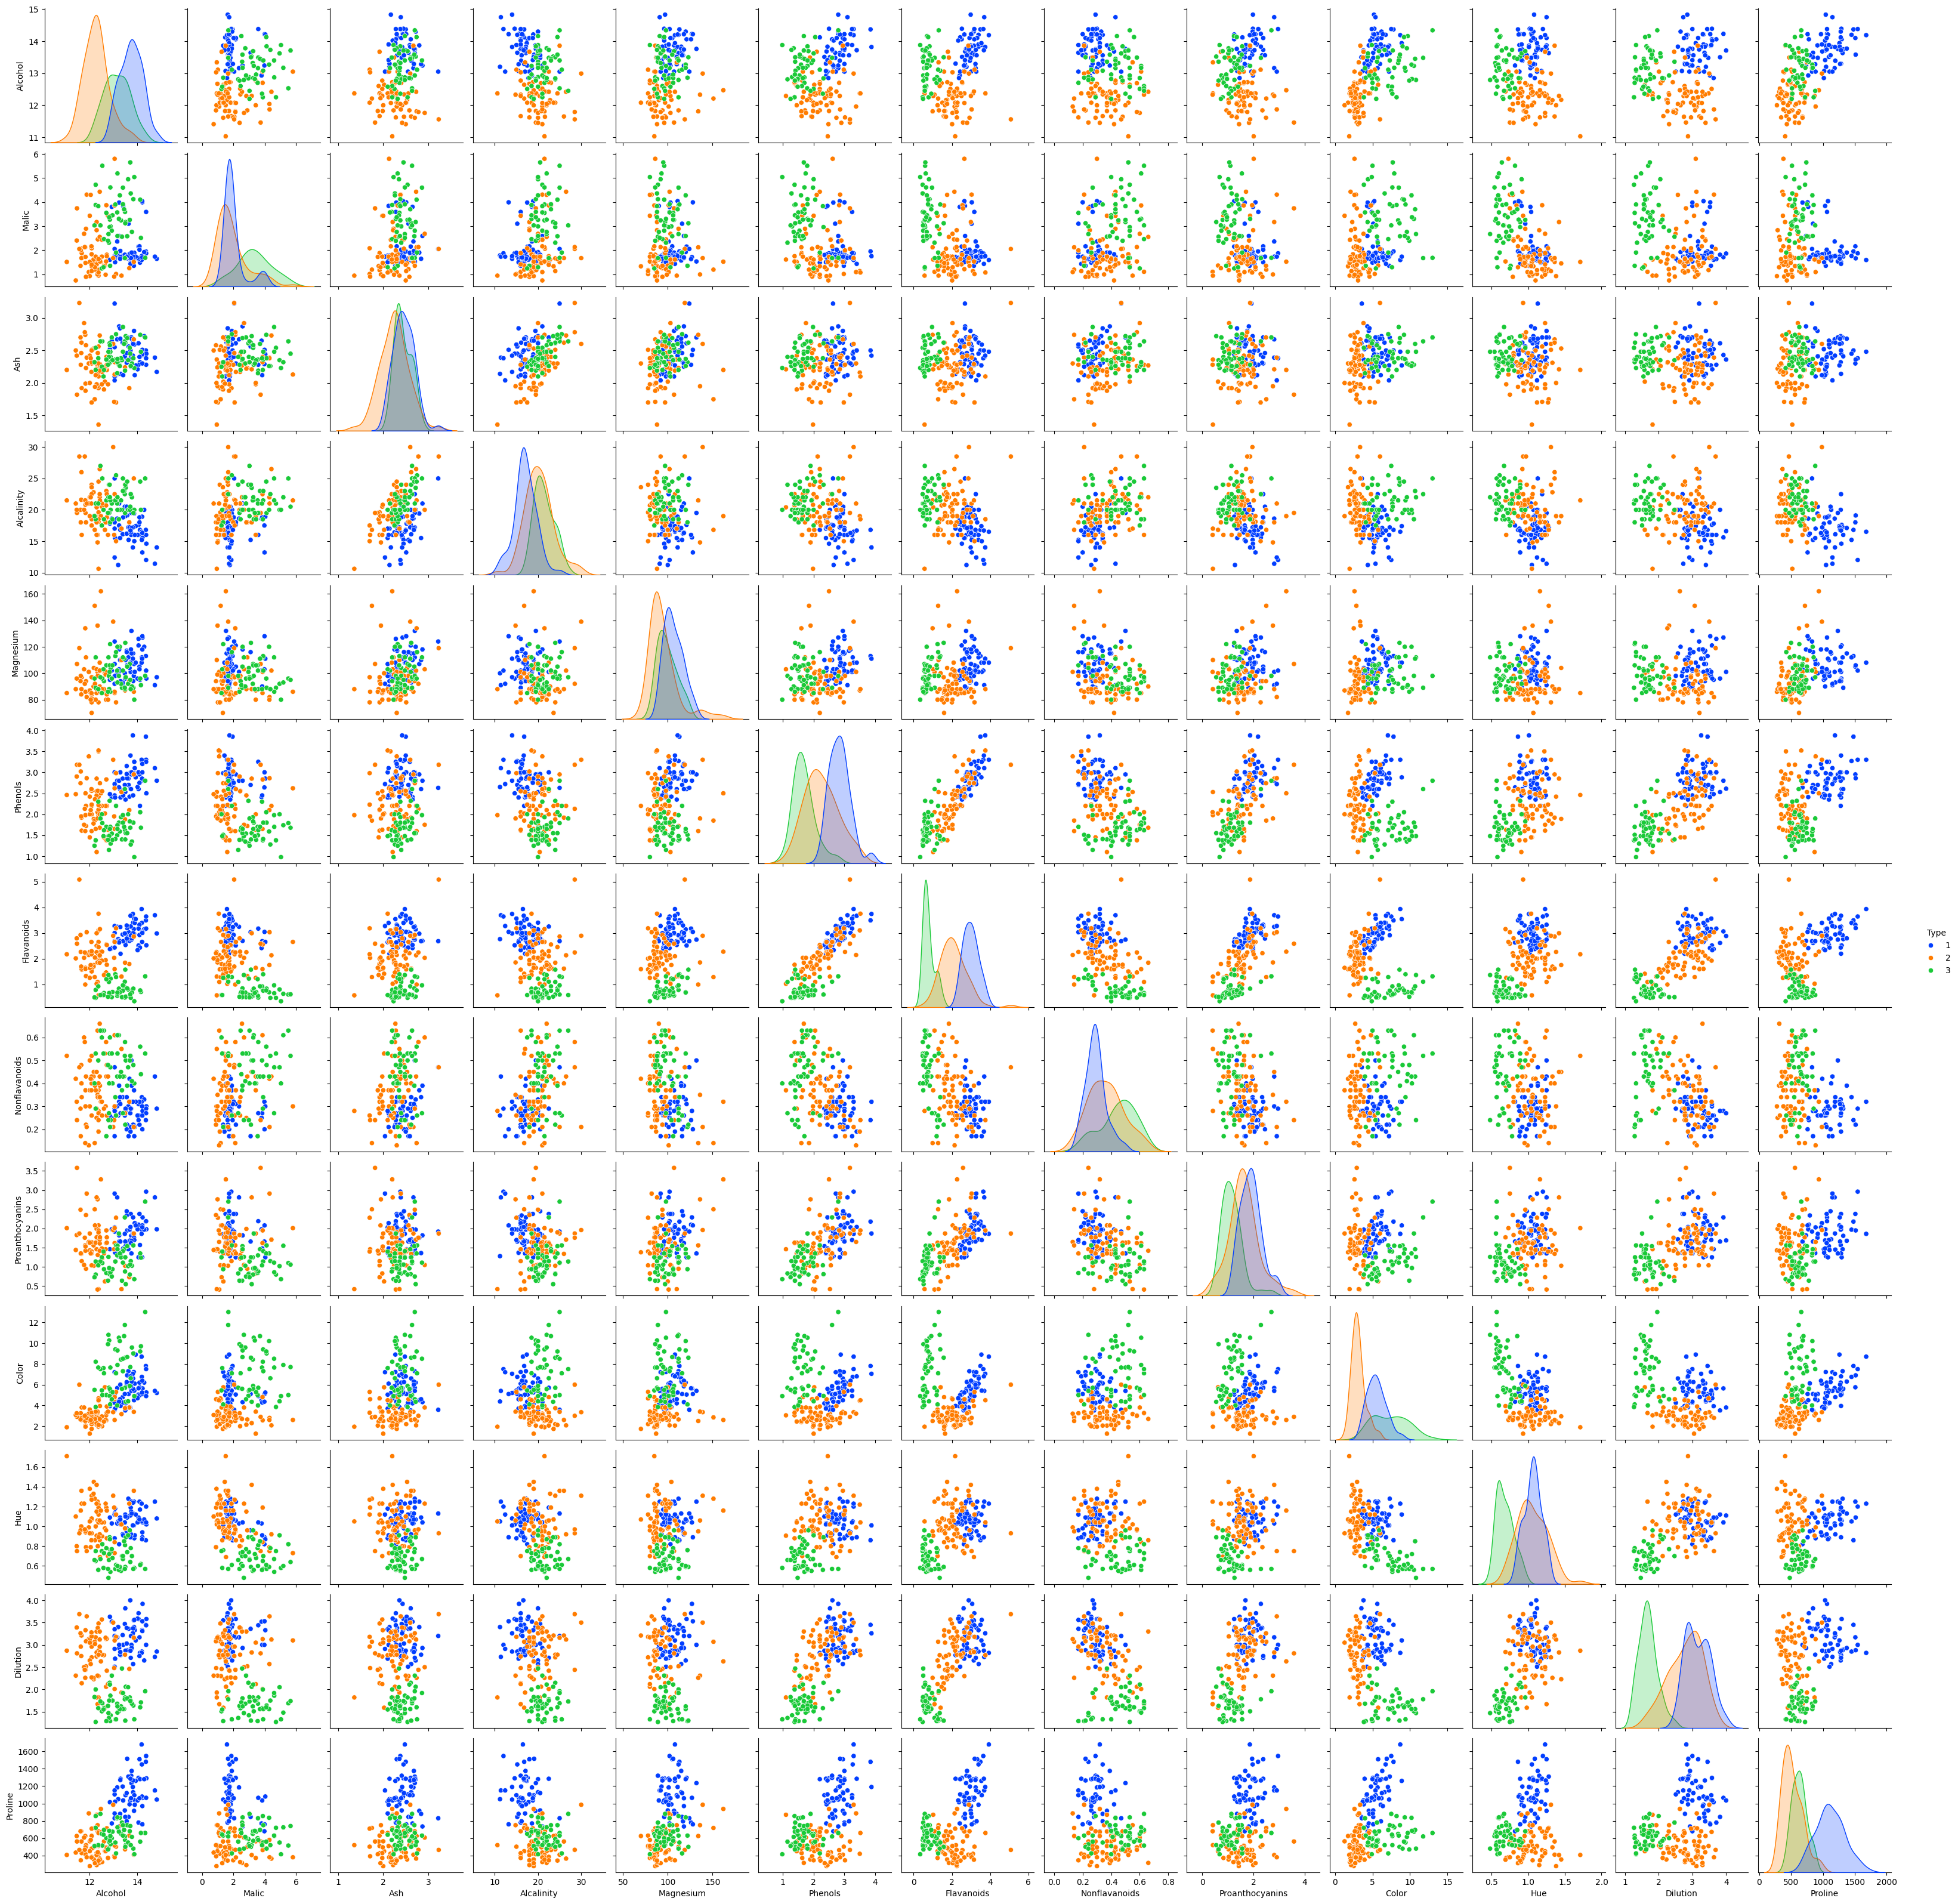

In [14]:
sns.pairplot(raw_data,palette="bright", hue='Type')

In [15]:
data =raw_data.drop('Type',axis=1)

In [16]:
standard_scaler = StandardScaler()
scaled_data = standard_scaler.fit_transform(data)
scaled_data.shape

(178, 13)

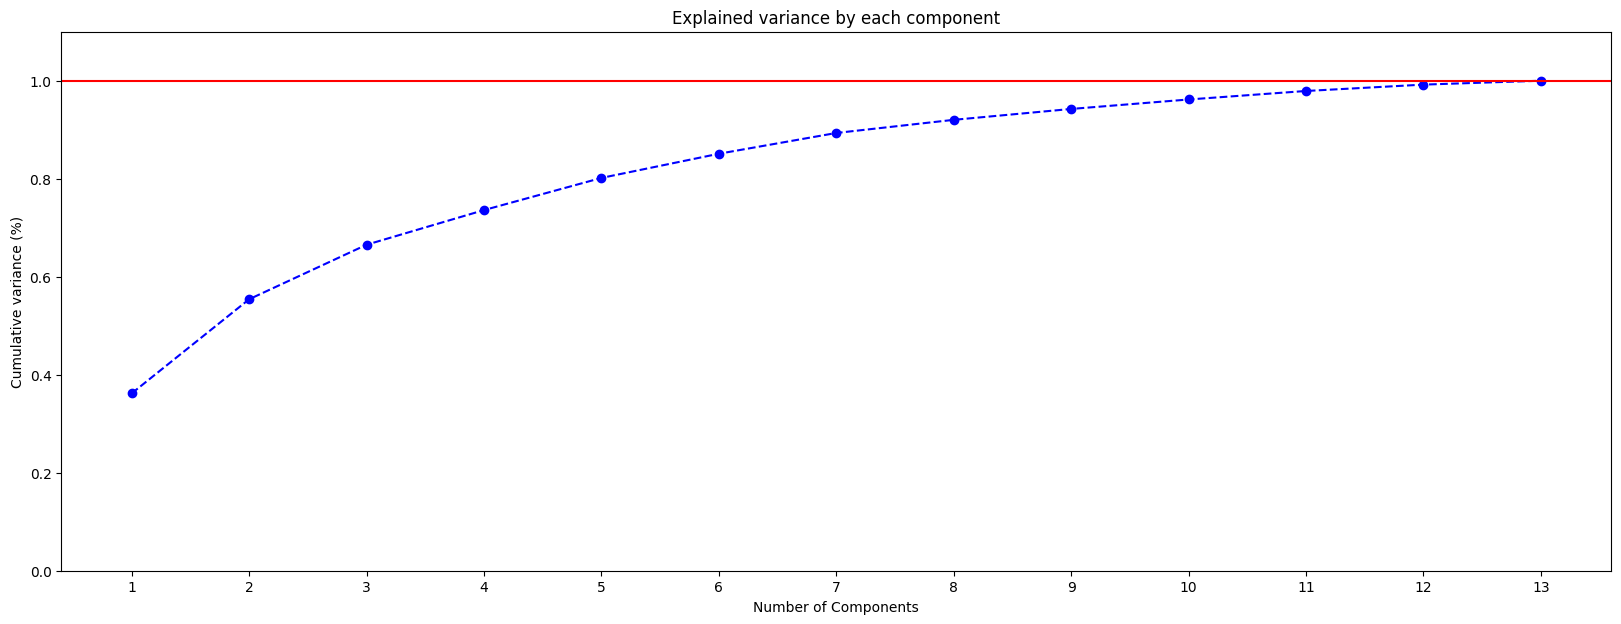

In [17]:
pca_variance = PCA()
pca_variance.fit(scaled_data)

plt.figure(figsize=(20,7))
xi = np.arange(1, 1+scaled_data.shape[1], step=1)
yi = np.cumsum(pca_variance.explained_variance_ratio_)
plt.plot(xi, yi, marker='o', linestyle='--', color='b')

plt.ylim(0.0,1.1)
plt.xlabel('Number of Components')
plt.xticks(np.arange(1, 1+scaled_data.shape[1], step=1))
plt.ylabel('Cumulative variance (%)')
plt.title('Explained variance by each component')
plt.axhline(y=1, color='r', linestyle='-')
plt.gca().xaxis.grid(False)

In [18]:
pca = PCA(n_components=3)
pca_scaled = pca.fit_transform(scaled_data)

pca_sc_df = pd.DataFrame(data = pca_scaled, columns = ['pc1', 'pc2','pc3'])
pca_sc_df.head()

,pc1,pc2,pc3
0,3.316751,1.443463,-0.165739
1,2.209465,-0.333393,-2.026457
2,2.516740,1.031151,0.982819
3,3.757066,2.756372,-0.176192
4,1.008908,0.869831,2.026688


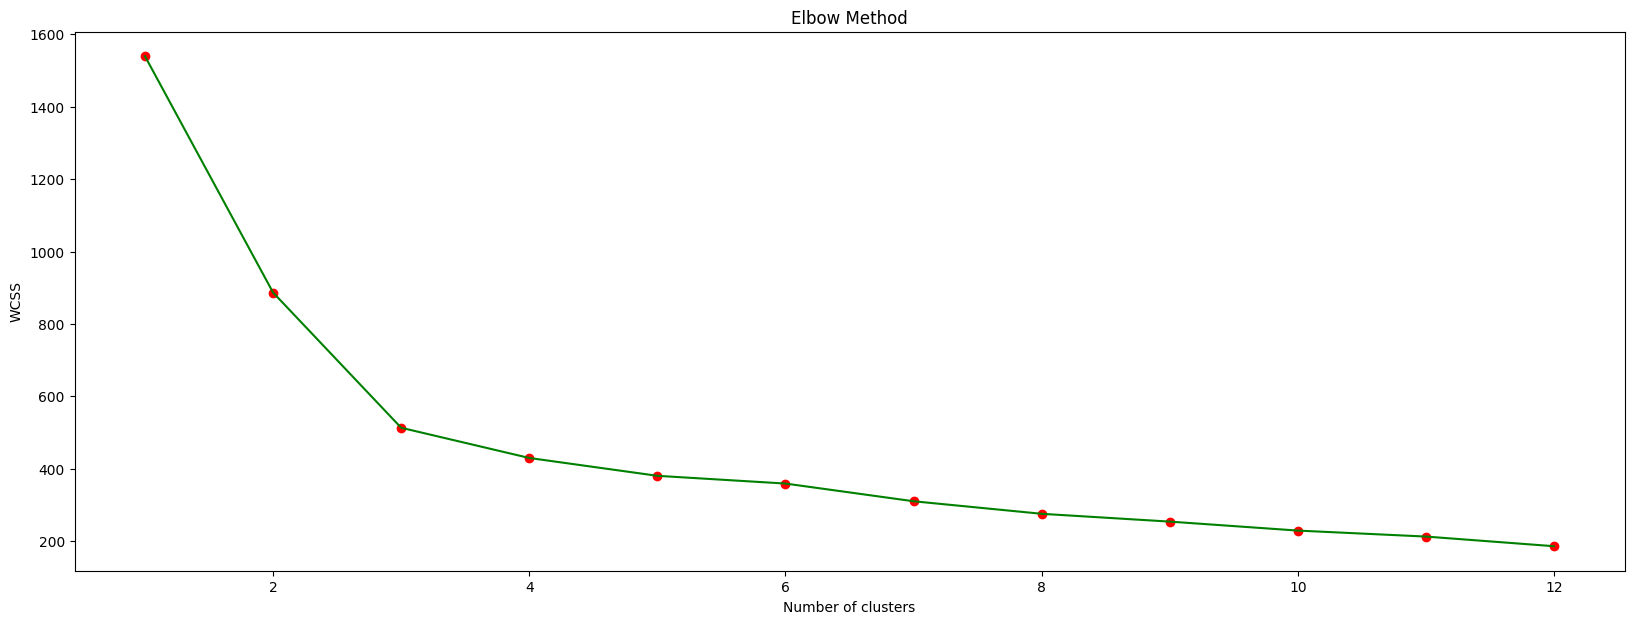

In [19]:
wcss = []
for i in range(1, 13):
    kmeans = KMeans(n_clusters=i,random_state=0)
    kmeans.fit(pca_sc_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(20,7))
plt.plot(range(1, 13), wcss,color='green')
plt.scatter(range(1,13),wcss,color='red')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

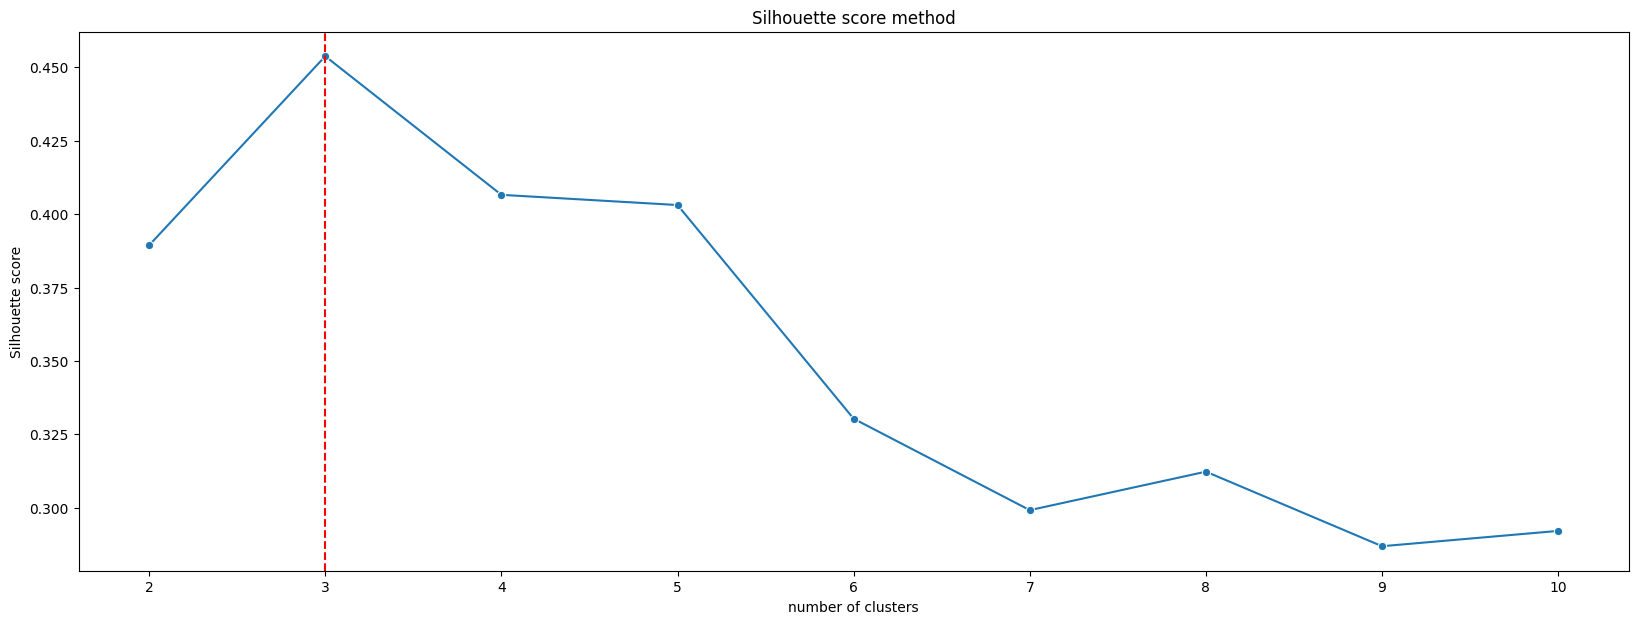

In [22]:
from sklearn.metrics import silhouette_score
n_clusters = [2,3,4,5,6,7,8,9,10]
clusters_inertia = []
s_scores = []

for n in n_clusters:
    KM_est = KMeans(n_clusters=n, init='k-means++').fit(pca_sc_df)
    clusters_inertia.append(KM_est.inertia_)
    silhouette_avg = silhouette_score(pca_sc_df, KM_est.labels_)
    s_scores.append(silhouette_avg)

fig, ax = plt.subplots(figsize=(20,7))
ax = sns.lineplot(x=n_clusters, y=s_scores, marker='o', ax=ax)
ax.set_title("Silhouette score method")
ax.set_xlabel("number of clusters")
ax.set_ylabel("Silhouette score")
ax.axvline(3, ls="--", c="red")
plt.show()

In [23]:
kmeans_clf = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 7)
prediction_kmeans = kmeans_clf.fit_predict(pca_sc_df)
prediction_kmeans

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

Text(0, 0.5, 'Euclidean distances')

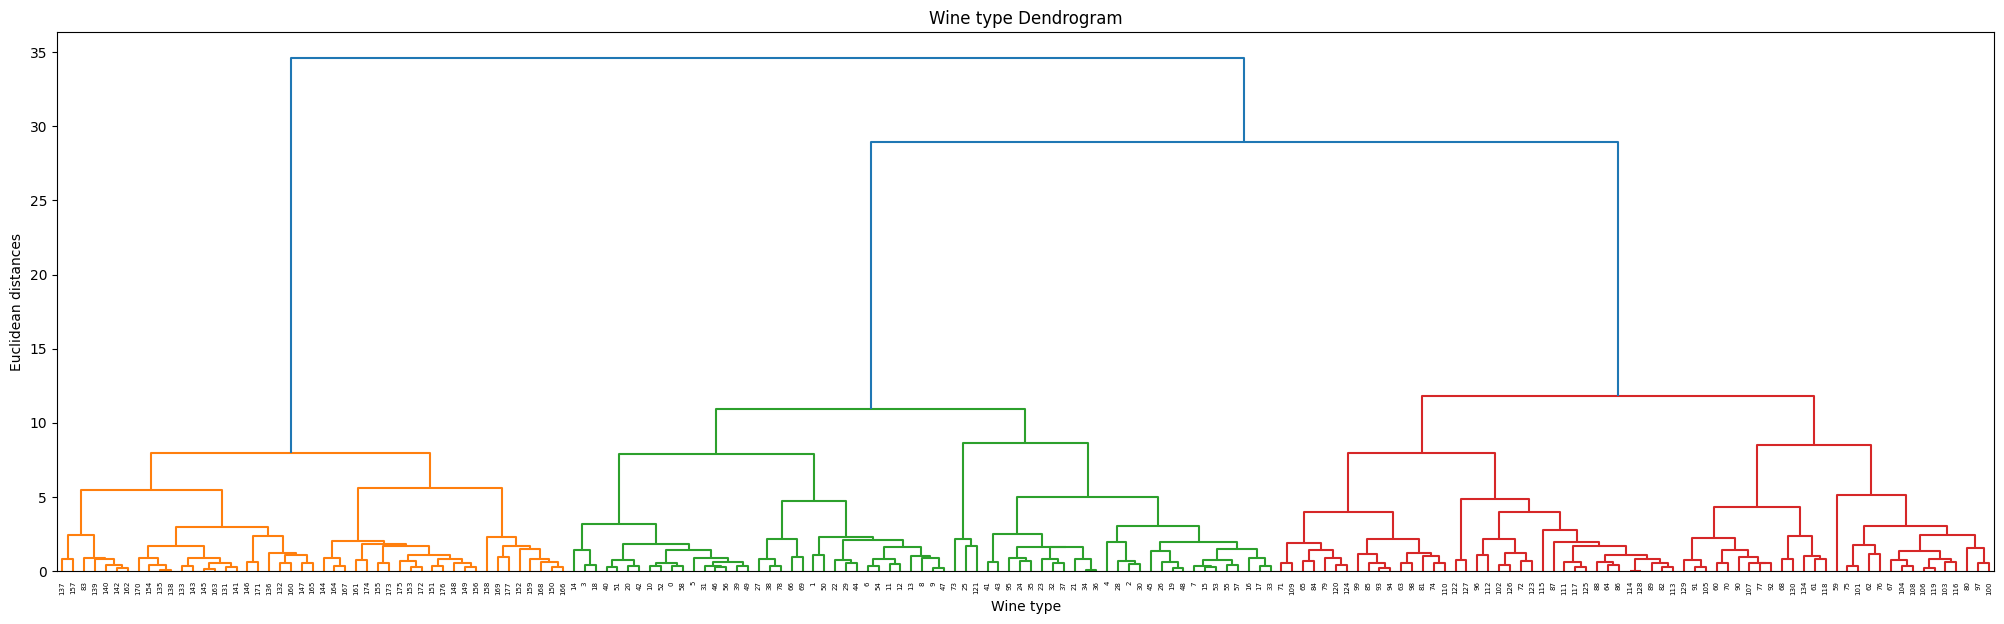

In [24]:
plt.figure(figsize=(25,7))
dendrogram_ward = sch.dendrogram(sch.linkage(pca_sc_df, method  = "ward"))
plt.title('Wine type Dendrogram')
plt.xlabel('Wine type')
plt.ylabel('Euclidean distances')

In [27]:
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
prediction_hier = agg_clustering.fit_predict(pca_sc_df)

In [28]:
data['Type_actual'] = raw_data['Type']
data['Type_kmeans'] = prediction_kmeans
data['Type_hier'] = prediction_hier
data.head()

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Type_actual,Type_kmeans,Type_hier
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1,1,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1,1,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1,1,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1,1,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1,1,2


In [29]:
data.groupby('Type_actual').agg(['mean'])

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Type_kmeans,Type_hier
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Type_actual,,,,,,,,,,,,,,,
1,13.744746,2.010678,2.455593,17.037288,106.338983,2.840169,2.982373,0.290000,1.899322,5.528305,1.062034,3.157797,1115.711864,1.000000,2.000000
2,12.278732,1.932676,2.244789,20.238028,94.549296,2.258873,2.080845,0.363662,1.630282,3.086620,1.056282,2.785352,519.507042,0.140845,0.183099
3,13.153750,3.333750,2.437083,21.416667,99.312500,1.678750,0.781458,0.447500,1.153542,7.396250,0.682708,1.683542,629.895833,2.000000,0.958333


In [30]:
data.groupby('Type_kmeans').agg(['mean'])

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Type_actual,Type_hier
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Type_kmeans,,,,,,,,,,,,,,,
0,12.249062,1.910313,2.233281,20.087500,92.812500,2.227813,2.023438,0.359531,1.619063,2.949219,1.063063,2.803906,507.828125,2.000000,0.093750
1,13.656032,1.983175,2.460476,17.479365,107.650794,2.858254,3.015079,0.291270,1.922540,5.438413,1.065079,3.157143,1093.238095,1.063492,1.968254
2,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824,2.941176,0.921569


In [31]:
data.groupby('Type_hier').agg(['mean'])

,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline,Type_actual,Type_kmeans
,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
Type_hier,,,,,,,,,,,,,,,
0,12.264242,1.932121,2.245455,20.087879,91.666667,2.220152,1.991364,0.367727,1.540455,3.036364,1.042515,2.729848,504.439394,2.030303,0.136364
1,13.171489,3.431702,2.441064,21.595745,98.829787,1.674894,0.792979,0.452766,1.165957,7.452553,0.682979,1.702553,627.021277,2.978723,2.000000
2,13.624769,1.954769,2.435538,17.373846,108.600000,2.819692,2.961692,0.290154,1.949385,5.379538,1.069538,3.149077,1079.753846,1.092308,0.953846


In [32]:
print(data['Type_actual'].value_counts())
print(data['Type_kmeans'].value_counts())
print(data['Type_hier'].value_counts())

Type_actual
2    71
1    59
3    48
Name: count, dtype: int64
Type_kmeans
0    64
1    63
2    51
Name: count, dtype: int64
Type_hier
0    66
2    65
1    47
Name: count, dtype: int64


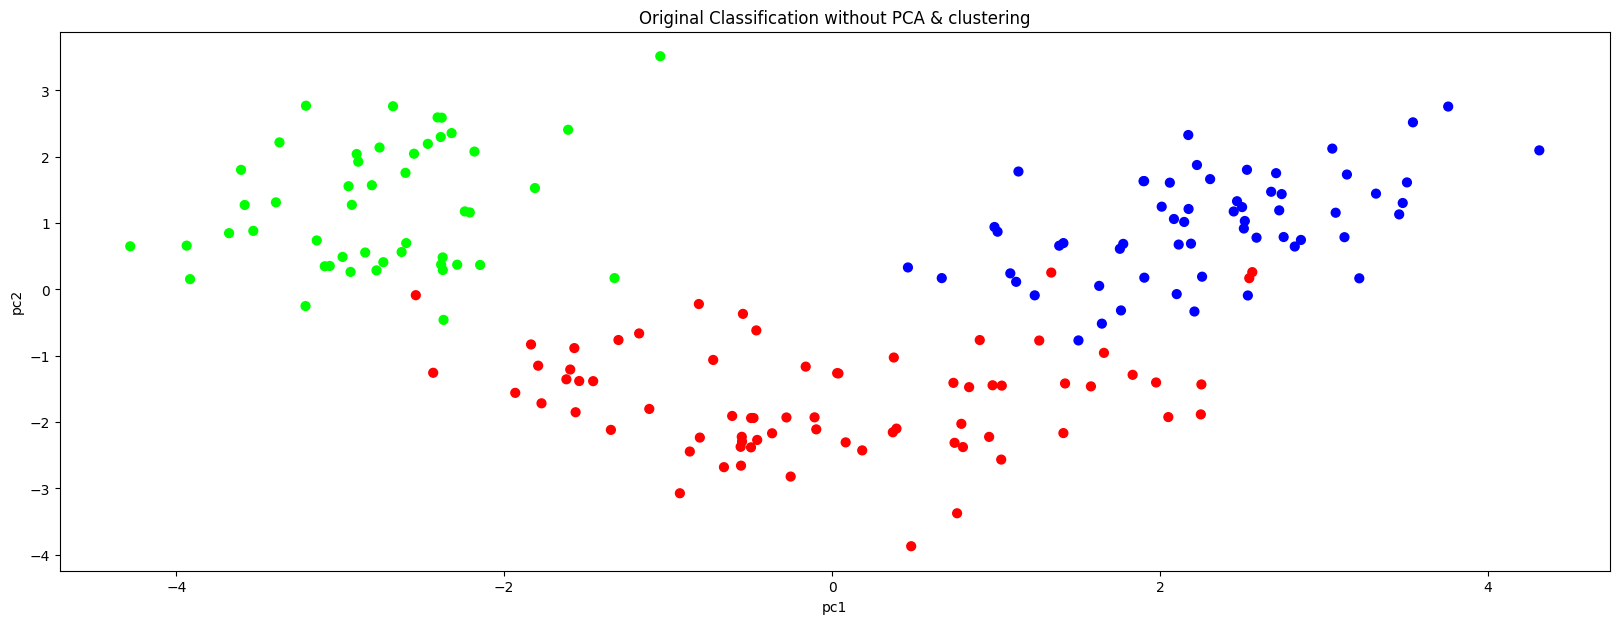

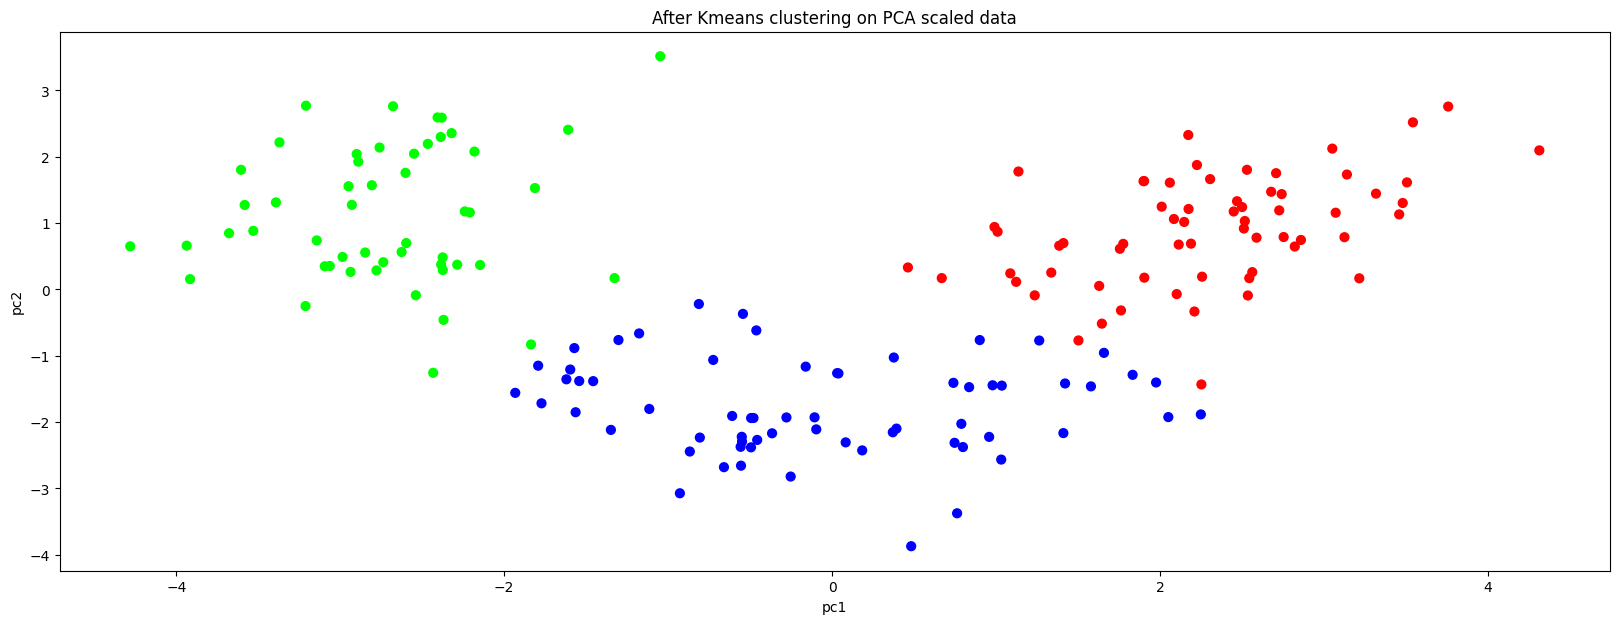

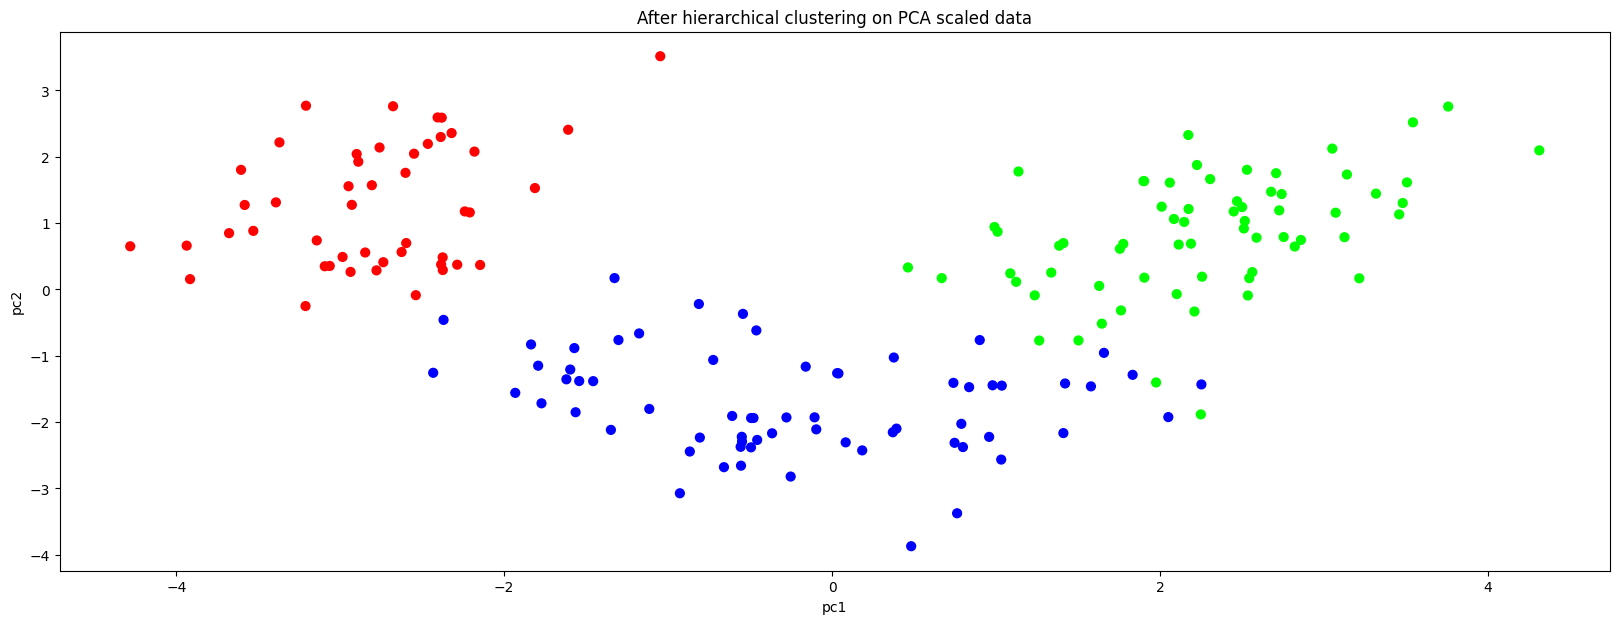

In [33]:
plt.figure(figsize=(20,7))
plt.scatter(pca_sc_df.iloc[:,0], pca_sc_df.iloc[:,1], c=data['Type_actual'], cmap="brg", s=40)
plt.title('Original Classification without PCA & clustering')
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.show()

plt.figure(figsize=(20,7))
plt.scatter(pca_sc_df.iloc[:,0], pca_sc_df.iloc[:,1], c=data['Type_kmeans'], cmap="brg", s=40)
plt.title('After Kmeans clustering on PCA scaled data')
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.show()

plt.figure(figsize=(20,7))
plt.scatter(pca_sc_df.iloc[:,0], pca_sc_df.iloc[:,1], c=data['Type_hier'], cmap="brg", s=40)
plt.title('After hierarchical clustering on PCA scaled data')
plt.xlabel('pc1')
plt.ylabel('pc2')
plt.show()

In [34]:
df = data.copy()

In [61]:
df['Type_changed'] = data['Type_actual']

In [62]:
df['Type_changed'] = df['Type_changed'].replace([1,2,3],[2,0,1])

In [63]:
Type_changed= df["Type_changed"].values
Type_kmeans = df["Type_kmeans"].values
Type_hier = df["Type_hier"].values

accuracy_kmeans = accuracy_score(Type_changed, Type_kmeans)
accuracy_hier = accuracy_score(Type_changed, Type_hier)

In [64]:
print('Kmeans accuracy : ', accuracy_kmeans*100)
print('Hierarchy accuracy : ',accuracy_hier*100)

Kmeans accuracy :  35.95505617977528
Hierarchy accuracy :  94.9438202247191


In [40]:
def EM_algorithm_step_optim(pi, mu, sigma, x, n, F):
  p = np.zeros((F,n))
  if sigma.ndim <= 1:
    for y in range(F):
      p[y] = np.exp(-(x-mu[y])**2/(2*sigma[y]))/np.sqrt(2*np.pi*sigma[y])
  else:
    d = x[0].shape[0]
    for y in range(F):
      p[y] = np.exp(-np.einsum('ij, jk, ik -> i', (x-mu[y]), np.linalg.inv(sigma[y]), (x-mu[y]))/2)/np.sqrt((2*np.pi)**d*abs(np.linalg.det(sigma[y])))
  p = p.transpose()
  rho = (pi*p).transpose()/np.sum(pi*p, axis = 1)
  new_pi = np.mean(rho, axis = 1)
  new_mu = ((rho@x).transpose()/np.sum(rho, axis = 1)).transpose()
  new_sigma = np.empty_like(sigma)
  if sigma.ndim <= 1:
    for y in range(F):
      new_sigma[y] = np.sum(rho[y]*(x - new_mu[y])**2)/np.sum(rho[y])
  else:
    for y in range(F):
      new_sigma[y] = np.einsum('i, ij, ik-> jk',rho[y], (x-mu[y]), (x-mu[y]))/np.sum(rho[y])
  return new_pi, new_mu, new_sigma

def EM_algorithm_optim(pi0: np.array, mu0: np.array, sigma0: np.array, x: np.array, n: int, F: int):
  pi, mu, sigma = pi0, mu0, sigma0
  liste_pi, liste_mu, liste_sigma = [np.copy(pi0)], [np.copy(mu0)], [np.copy(sigma0)]
  j=0
  while j<200 and (len(liste_pi) <= 2
    or np.linalg.norm(liste_pi[-1] - liste_pi[-2])+np.linalg.norm(liste_mu[-1] - liste_mu[-2])+np.linalg.norm(liste_sigma[-1] - liste_sigma[-2]) > 0.001):
    pi, mu, sigma = EM_algorithm_step_optim(pi, mu, sigma, x, n, F)
    liste_pi.append(np.copy(pi))
    liste_mu.append(np.copy(mu))
    liste_sigma.append(np.copy(sigma))
    j += 1
  return pi, mu, sigma, liste_pi, liste_mu, liste_sigma

In [66]:
def nearest_neighbor(query, data):
    # Calculate L2 distances between the query vector and all data vectors
    if data.ndim > 1:
      distances = np.linalg.norm(data - query, axis = 1)
    else:
      distances = abs(data-query)

    # Find the index of the nearest neighbor
    nearest_index = np.argmin(distances)

    return nearest_index

def kmeans_step(centroid : np.array, x : np.array):
    nearest_index = np.array([nearest_neighbor(e, centroid) for e in x])
    return np.array([np.mean(x[nearest_index == i], axis = 0) for i in range(len(centroid))])


def kmeans(k, x):
  centroid = x[:k]*0
  np.random.shuffle(x)
  new_centroid = x[:k]
  i = 0
  while np.linalg.norm(centroid - new_centroid) > 0.001 and i < 100:
    i += 1
    centroid = new_centroid
    new_centroid = kmeans_step(centroid, x)
  return centroid


In [74]:
echantillon = pca_sc_df.to_numpy(dtype = np.float128)
N = data.shape[0]
F = 3
pi0 = np.ones(F)/F
mu0 = kmeans(F, echantillon)
sigma0 = np.array([np.eye(echantillon.shape[1]) for _ in range(F)])/F/F

pi, mu, sigma, liste_pi, liste_mu, liste_sigma = EM_algorithm_optim(pi0, mu0, sigma0, echantillon, N, F)

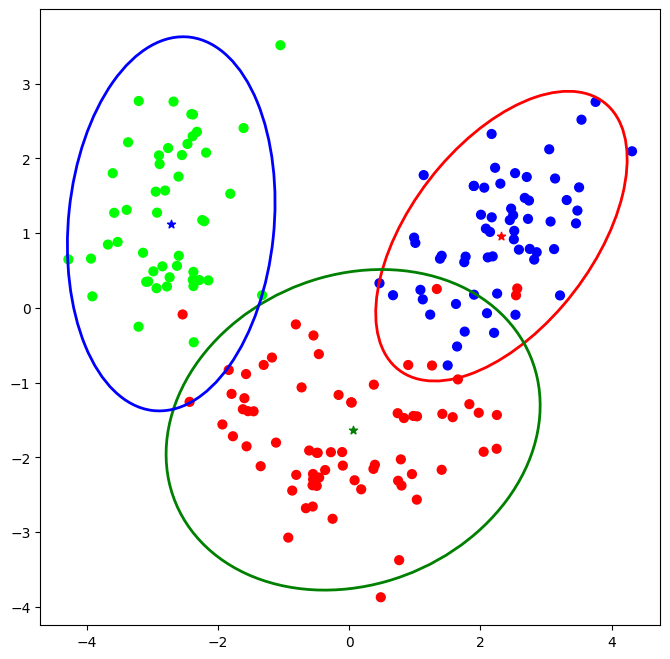

In [75]:
from matplotlib.patches import Ellipse
couleurs = ['red', 'green', 'blue', 'orange', 'purple', 'brown', 'pink', 'olive']

plt.figure(figsize=(8, 8))
plt.scatter(pca_sc_df.iloc[:,0], pca_sc_df.iloc[:,1], c=data['Type_actual'], cmap="brg", s=40)

# Adding centres of mass and ellipses
for y in range(F):
  # Centre of mass
  plt.scatter(mu[y,0], mu[y, 1], color=couleurs[y], marker="*")

  # Ellipse
  # Construct the ellipse
  eigenvalues, eigenvectors = np.linalg.eigh(sigma[y,0:2,0:2]) # Eigenvalues and eigenvectors of the covariance matrix
  angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))  # Rotation angle
  width, height = 2 * np.sqrt(6*eigenvalues) # Width and height of ellipse
   # (scaled by 6 which is the quantile of order 95% of the chi2 distribution with 2 dof)

  # Create ellipse patch
  ellipse = Ellipse(xy=mu[y,0:2], width=width, height=height, angle=angle,
                      edgecolor=couleurs[y], facecolor='none', linewidth=2)

  ax = plt.gca()
  ax.add_patch(ellipse)

plt.show()